In [34]:
import sys
from pathlib import Path
import numpy as np

src_path = Path.cwd().parent / "src"
sys.path.append(str(src_path.resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split        # from scikit-learn lib

from plotting import plot_histogram
from config import PATH_AMESHOUSING

In [35]:
# READ THE CSV DATA
df = pd.read_csv(PATH_AMESHOUSING)

# Step 1 - Explore and understand the data

In [36]:
# the available variables and their data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

count   2.93e+03
mean    1.81e+05
std     7.99e+04
min     1.28e+04
25%     1.30e+05
50%     1.60e+05
75%     2.14e+05
max     7.55e+05
Name: SalePrice, dtype: float64
Axes(0.125,0.11;0.775x0.77)


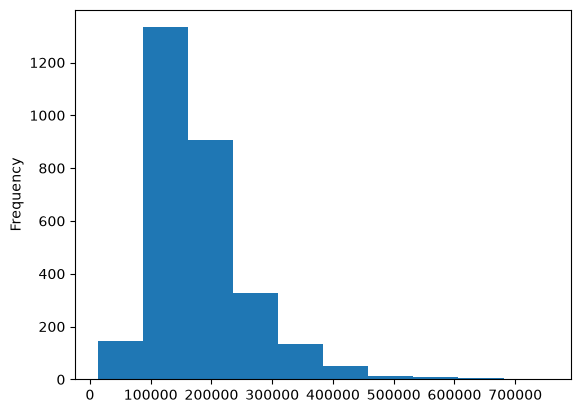

In [37]:
# the distribution of SalePrice
print(df["SalePrice"].describe())

print(df["SalePrice"].plot(kind="hist"))

In [38]:
# missing values
df.isna().sum().sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64

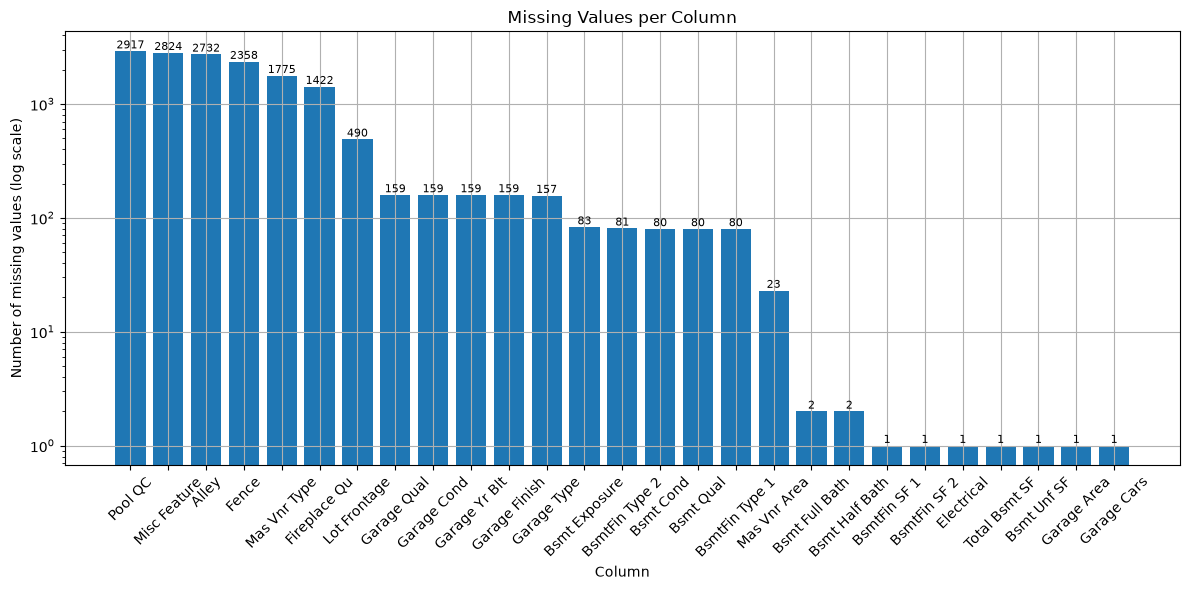

In [39]:
# Fillip's code:
NanValues = df.isnull().sum()
NanValues = NanValues[NanValues > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(NanValues.index, NanValues.values)

plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel("Number of missing values (log scale)")
plt.xlabel("Column")
plt.title("Missing Values per Column")
plt.grid()

# Add the actual count on top of each bar
for bar, value in zip(bars, NanValues.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
              str(value), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [40]:
# checking values of categories showing signs of having outliers when using graph of 'missing values per column' (Fillip's code)
print(df["Pool QC"].value_counts()) # little useful
print(df["Misc Feature"].value_counts()) 
print(df["Alley"].value_counts()) 
print(df["Fence"].value_counts()) 
print(df["Mas Vnr Type"].value_counts()) 
print(df["Fireplace Qu"].value_counts()) 
print(df["Lot Frontage"].value_counts()) 
print(df["Garage Qual"].value_counts()) 
print(df["Garage Cond"].value_counts()) 
print(df["Garage Yr Blt"].value_counts()) 
print(df["Garage Finish"].value_counts())
print(df["Garage Type"].value_counts()) 
print(df["Bsmt Exposure"].value_counts()) 
print(df["BsmtFin Type 2"].value_counts()) 
print(df["Bsmt Cond"].value_counts())
print(df["Bsmt Qual"].value_counts()) 
print(df["BsmtFin Type 1"].value_counts()) 

Pool QC
Ex    4
Gd    4
TA    3
Fa    2
Name: count, dtype: int64
Misc Feature
Shed    95
Gar2     5
Othr     4
Elev     1
TenC     1
Name: count, dtype: int64
Alley
Grvl    120
Pave     78
Name: count, dtype: int64
Fence
MnPrv    330
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64
Mas Vnr Type
BrkFace    880
Stone      249
BrkCmn      25
CBlock       1
Name: count, dtype: int64
Fireplace Qu
Gd    744
TA    600
Fa     75
Po     46
Ex     43
Name: count, dtype: int64
Lot Frontage
6.00e+01    276
8.00e+01    137
7.00e+01    133
5.00e+01    117
7.50e+01    105
           ... 
1.68e+02      1
1.11e+02      1
1.31e+02      1
1.53e+02      1
1.33e+02      1
Name: count, Length: 128, dtype: int64
Garage Qual
TA    2615
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64
Garage Cond
TA    2665
Fa      74
Gd      15
Po      14
Ex       3
Name: count, dtype: int64
Garage Yr Blt
2.00e+03    142
2.01e+03    115
2.01e+03    115
2.00e+03     99
2.00e+03     92
    

In [41]:
# unusual values or patterns

df.describe().T
# The max value being much bigger than the 75% value indicates an outlier

,count,mean,std,min,25%,50%,75%,max
Order,2.93e+03,1.47e+03,8.46e+02,1.00e+00,7.33e+02,1.47e+03,2.20e+03,2.93e+03
PID,2.93e+03,7.14e+08,1.89e+08,5.26e+08,5.28e+08,5.35e+08,9.07e+08,1.01e+09
MS SubClass,2.93e+03,5.74e+01,4.26e+01,2.00e+01,2.00e+01,5.00e+01,7.00e+01,1.90e+02
Lot Frontage,2.44e+03,6.92e+01,2.34e+01,2.10e+01,5.80e+01,6.80e+01,8.00e+01,3.13e+02
Lot Area,2.93e+03,1.01e+04,7.88e+03,1.30e+03,7.44e+03,9.44e+03,1.16e+04,2.15e+05
Overall Qual,2.93e+03,6.09e+00,1.41e+00,1.00e+00,5.00e+00,6.00e+00,7.00e+00,1.00e+01
Overall Cond,2.93e+03,5.56e+00,1.11e+00,1.00e+00,5.00e+00,5.00e+00,6.00e+00,9.00e+00
Year Built,2.93e+03,1.97e+03,3.02e+01,1.87e+03,1.95e+03,1.97e+03,2.00e+03,2.01e+03
Year Remod/Add,2.93e+03,1.98e+03,2.09e+01,1.95e+03,1.96e+03,1.99e+03,2.00e+03,2.01e+03
Mas Vnr Area,2.91e+03,1.02e+02,1.79e+02,0.00e+00,0.00e+00,0.00e+00,1.64e+02,1.60e+03


In [42]:
# checking values of categories showing signs of having outliers when using df.describe()
print(df["Low Qual Fin SF"].value_counts()) # little useful
print(df["TotRms AbvGrd"].value_counts())   # useful
print(df["Wood Deck SF"].value_counts())    # little useful
print(df["Open Porch SF"].value_counts())   # little useful
print(df["Enclosed Porch"].value_counts())  # little useful
print(df["3Ssn Porch"].value_counts())      # little useful
print(df["Screen Porch"].value_counts())    # little useful
print(df["Pool Area"].value_counts())       # little useful
print(df["Misc Val"].value_counts())        # little useful
print(df["Mo Sold"].value_counts())         # useful

Low Qual Fin SF
0       2890
80         4
360        2
205        2
390        1
362        1
144        1
1064       1
232        1
431        1
120        1
436        1
371        1
259        1
397        1
312        1
513        1
108        1
156        1
697        1
420        1
384        1
473        1
512        1
528        1
114        1
479        1
515        1
53         1
392        1
572        1
234        1
140        1
450        1
481        1
514        1
Name: count, dtype: int64
TotRms AbvGrd
6     844
7     649
5     586
8     347
4     203
9     143
10     80
11     32
3      26
12     16
13      1
2       1
15      1
14      1
Name: count, dtype: int64
Wood Deck SF
0      1526
100      74
192      70
144      61
168      56
       ... 
207       1
530       1
574       1
326       1
728       1
Name: count, Length: 380, dtype: int64
Open Porch SF
0      1300
36       52
48       52
40       44
32       38
       ... 
245       1
107       1
225       1
125 

<Axes: >

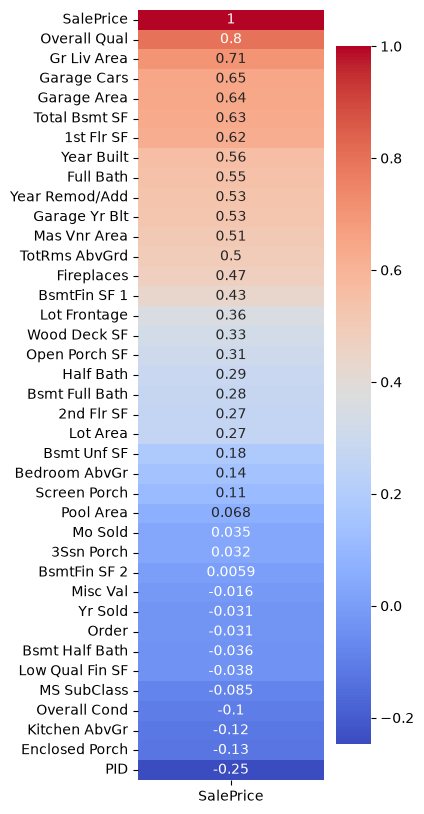

In [43]:
# relationships that may be useful for predicting house prices

# Heatmap for correlation (inspired by Kacper's code)
target_to_compare_to = df.corr(numeric_only = True)["SalePrice"].sort_values(ascending = False)

plt.figure(figsize = (3, 10))
sns.heatmap(target_to_compare_to.to_frame(), cmap = "coolwarm", annot = True, cbar = True)

Text(0.5, 0, 'Correlation coefficient')

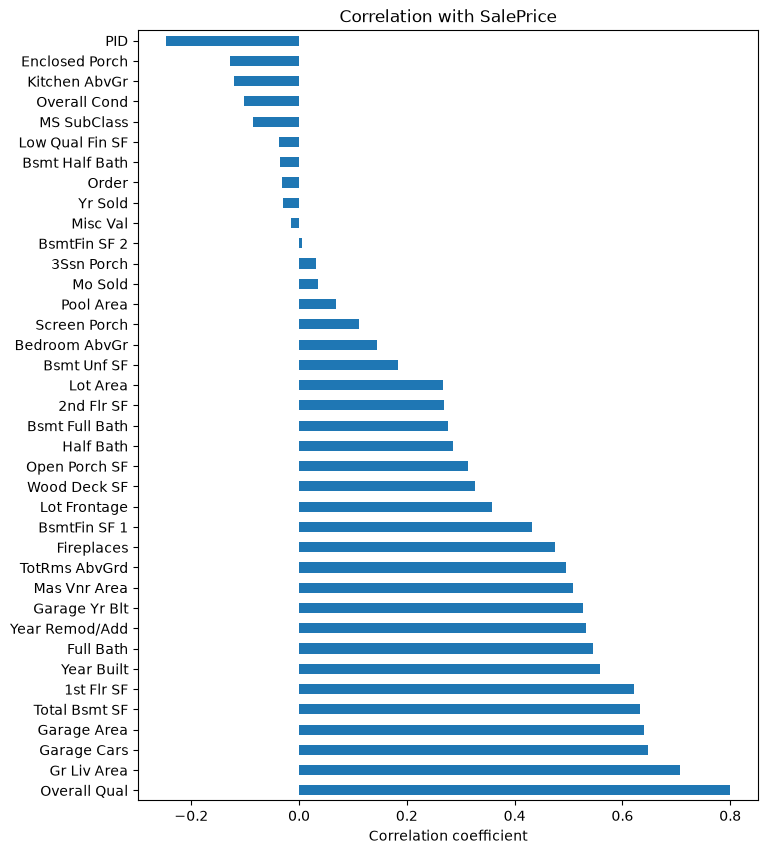

In [44]:
# a bit more visual, easier to read
plt.figure(figsize=(8, 10))
target_to_compare_to.drop("SalePrice").plot(kind="barh")
plt.title("Correlation with SalePrice")
plt.xlabel("Correlation coefficient")

# Step 2 - Split onto training and test sets

In [45]:
# splitting df into training and testing data
# test_size = 0.2 means 20% is held out for testing
# random_state = 13 means we use the same split every time we run notebook. makes it reproduceable(we can do the same again and again)
train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 13)

print(train_df.shape, test_df.shape)

# from here on, we will use train_df for all exploration/cleaning

(2344, 82) (586, 82)


# Step 3 - Prepare the data

<Axes: >

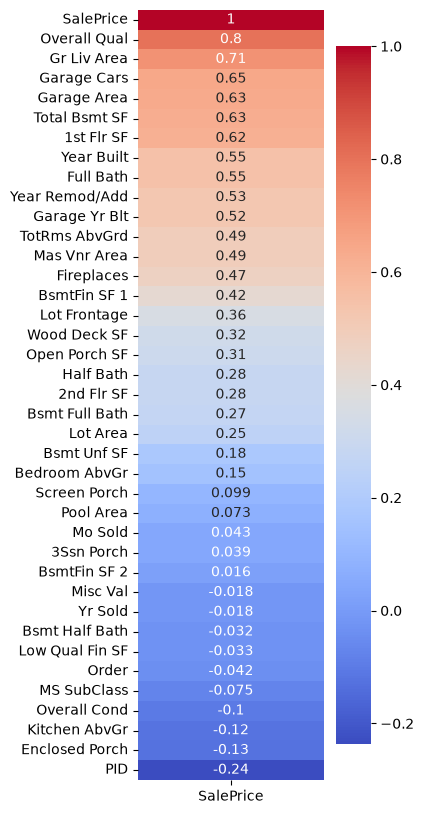

In [46]:
# examines what categories has highest correllation to SalePrice in test data
train_target_to_compare_to = train_df.corr(numeric_only = True)["SalePrice"].sort_values(ascending = False)

plt.figure(figsize = (3, 10))
sns.heatmap(train_target_to_compare_to.to_frame(), cmap = "coolwarm", annot = True, cbar = True)

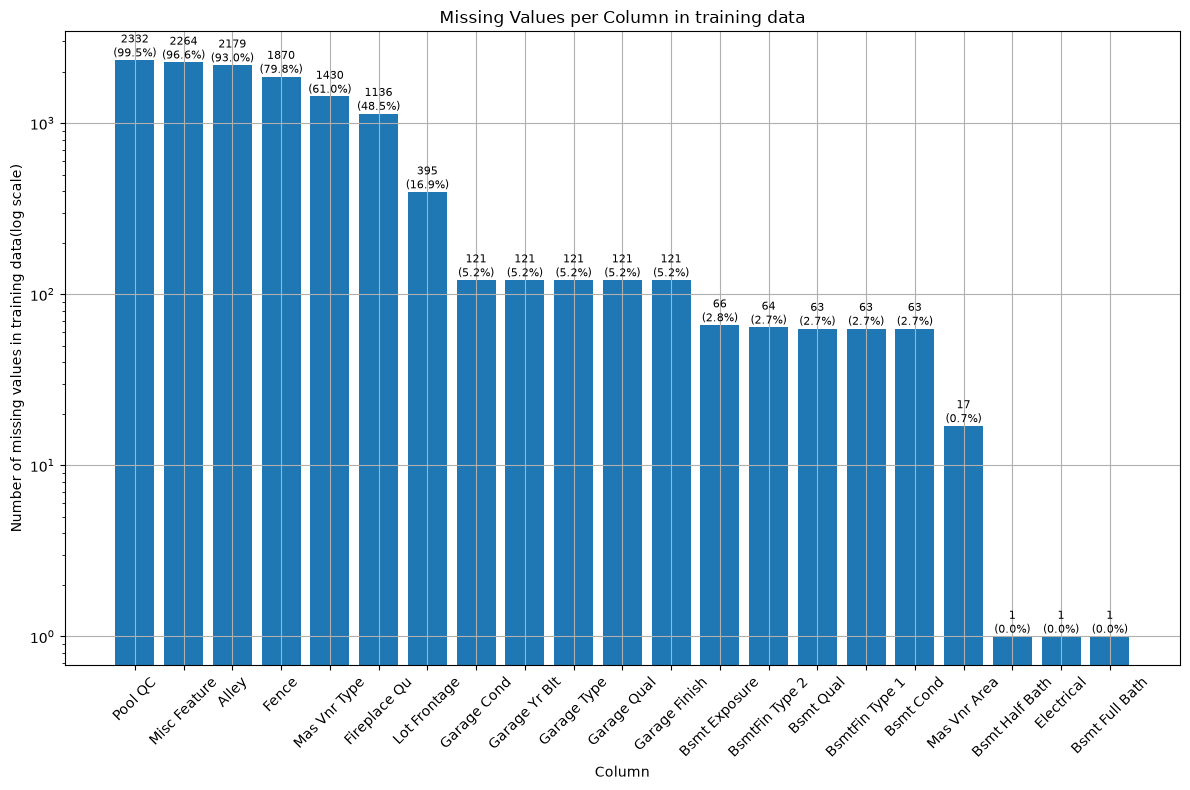

In [47]:
# Finds out how many missing values each category in the test data has
# inspired by Fillip's code:
train_NanValues = train_df.isnull().sum()
train_NanValues = train_NanValues[train_NanValues > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
bars = plt.bar(train_NanValues.index, train_NanValues.values)

plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel("Number of missing values in training data(log scale)")
plt.xlabel("Column")
plt.title("Missing Values per Column in training data")
plt.grid()

# Add the actual count(with percentage equivalent) on top of each bar
total_rows = len(train_df)
for bar, value in zip(bars, train_NanValues.values):
    pct = value / total_rows * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
              f"{value}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=8)
    

plt.tight_layout()
plt.show()

In [ ]:
# colums we are considering dropping (based on it missing more than 15% of the data):
cols_to_drop = ["Pool QC",
                "Misc Feature",
                "Alley",
                "Fence",
                "Mas Vnr Type",
                "Fireplace Qu",
                "Lot Frontage",     # numeric value, correlation to SalePrice = 0.36  
                # under here is all numeric columns with less than |0.25| correlation to SalePrice
                "Bsmt Unf SF",
                "Bedroom AbvGr",
                "Screen Porch",     
                "Pool Area",
                "Mo Sold",
                "3Ssn Porch",
                "BmtFin SF 2",
                "Misc Val",
                "Yr Sold",
                "Bsmt Half Bath",
                "Low Qual Fin SF",
                "Order",
                "MS SubClass",
                "Overall Cond",
                "Kitchen AbvGr",
                "Enclosed Porch",
                "PID",
                # under here is all word columns where one category overshadows the value of all others
                "Street",
                "Utilities",
                "Condition 2",
                "Roof Matl",
                "Heating",
                "Functional"
                ]

In [ ]:
# checking for outliers:
pd.options.display.float_format = "{:,.2e}".format
train_df.describe().T

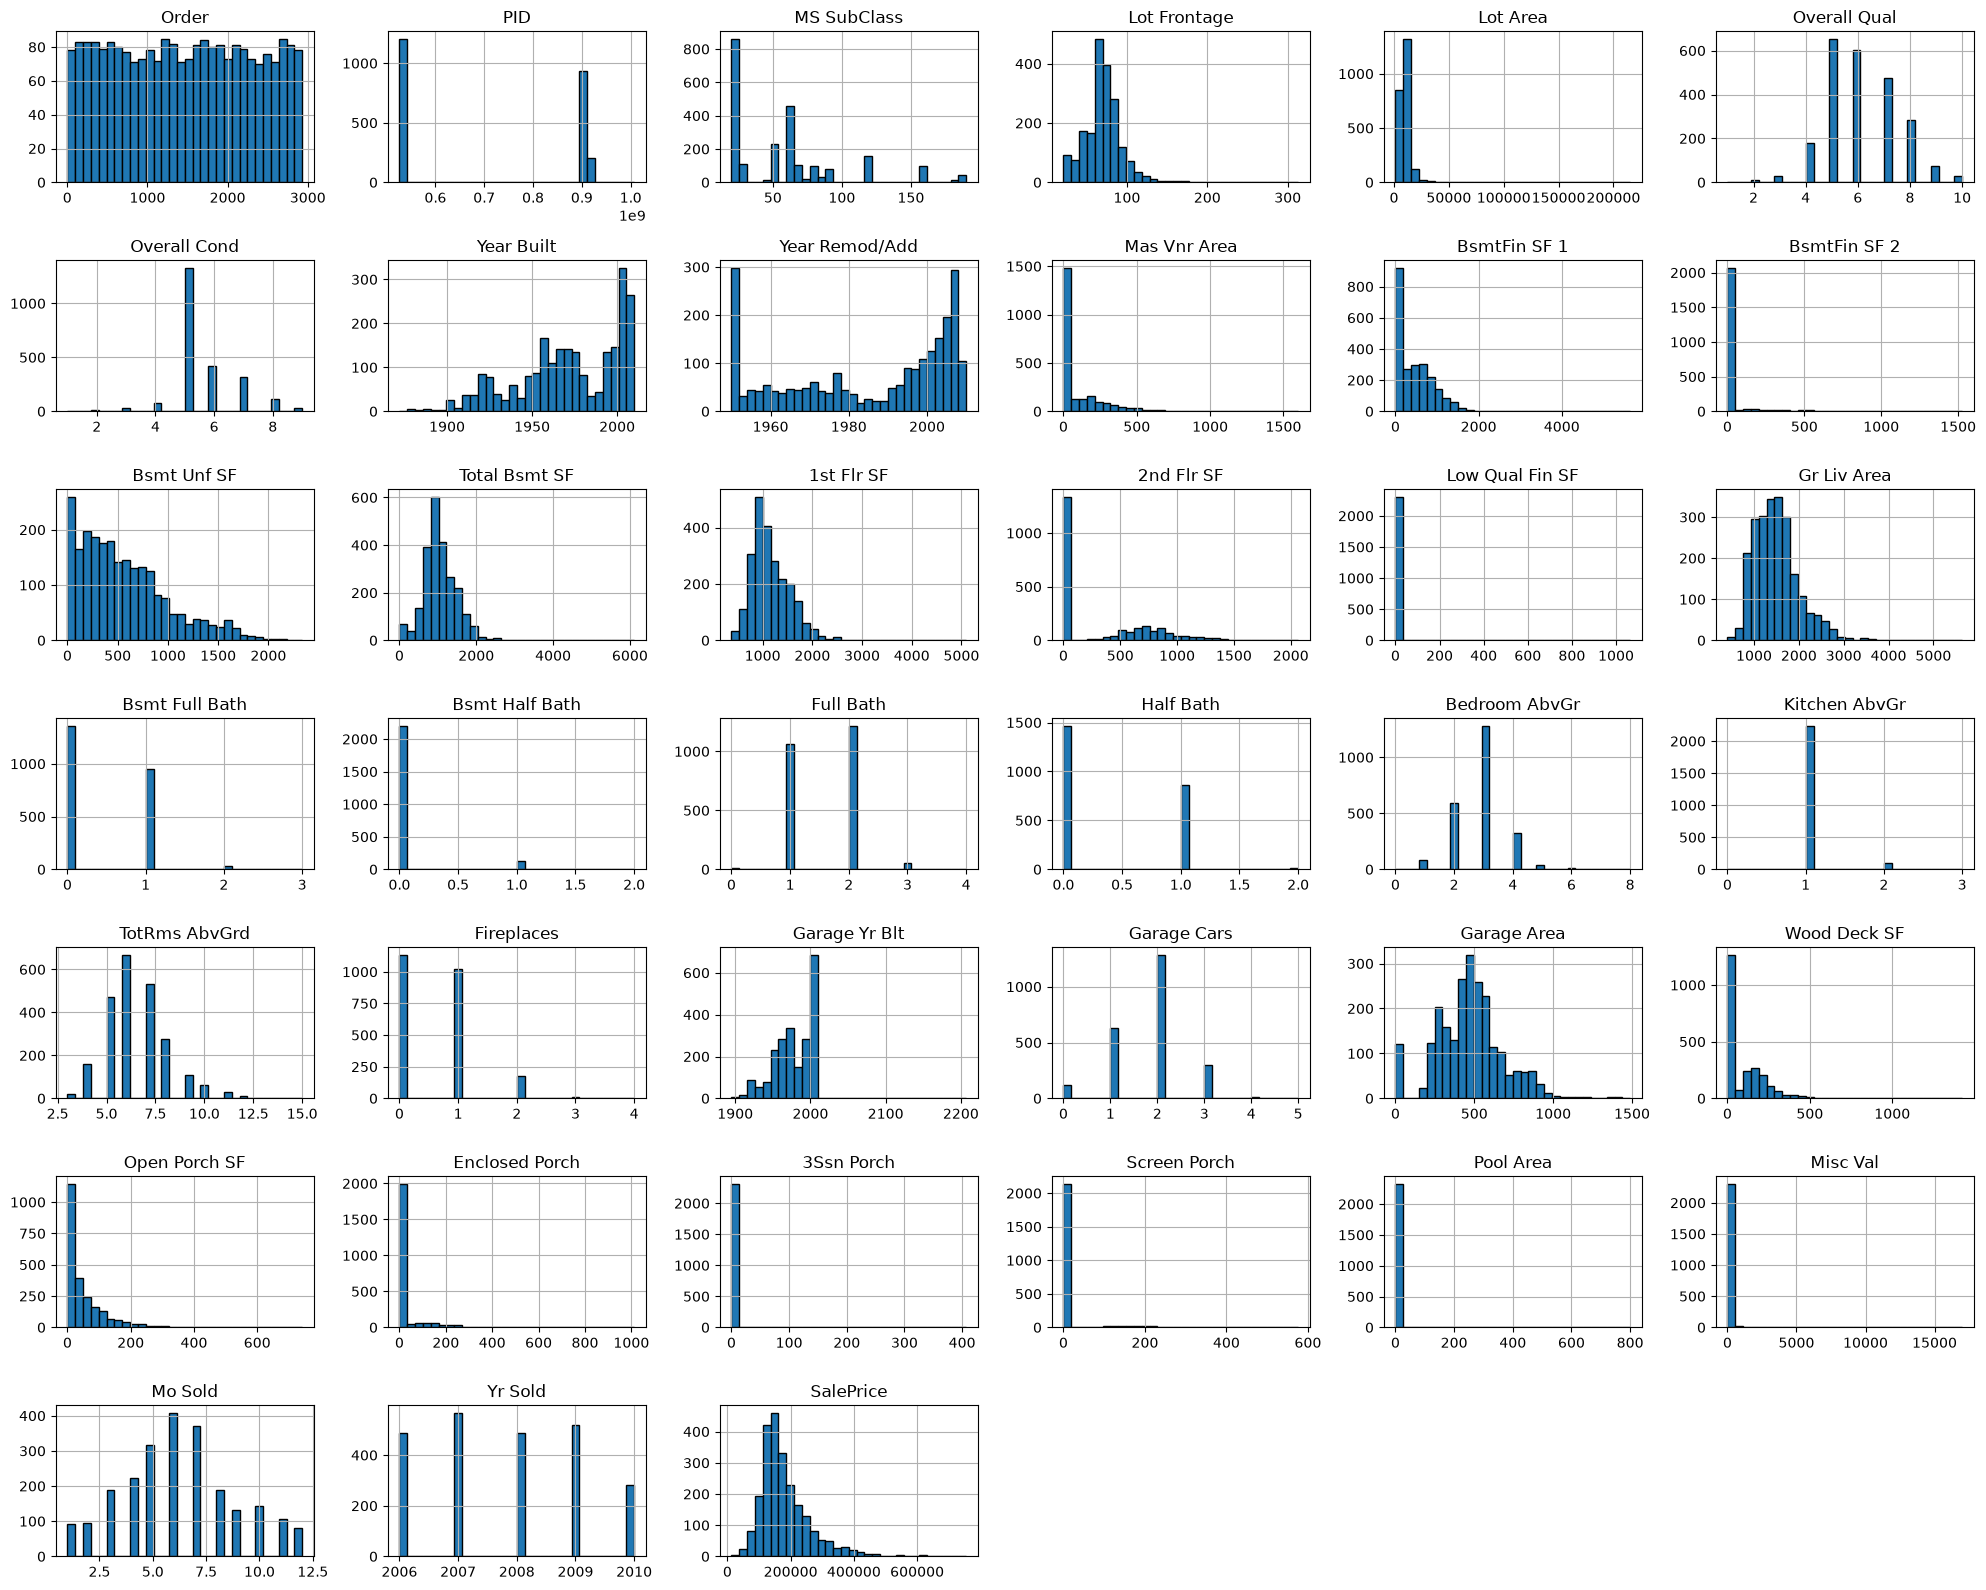

In [94]:
# checking values of categories in training data showing signs of having outliers when using train_df.describe()
numeric_cols = train_df.select_dtypes(include="number").columns

train_df[numeric_cols].hist(figsize=(20, 16), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

In [91]:
cat_cols = train_df.select_dtypes(exclude="number").columns
print(len(cat_cols), "categorical columns")
print(cat_cols.tolist())

cat_cols_filtered = [col for col in cat_cols if col not in cols_to_drop]

43 categorical columns
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']


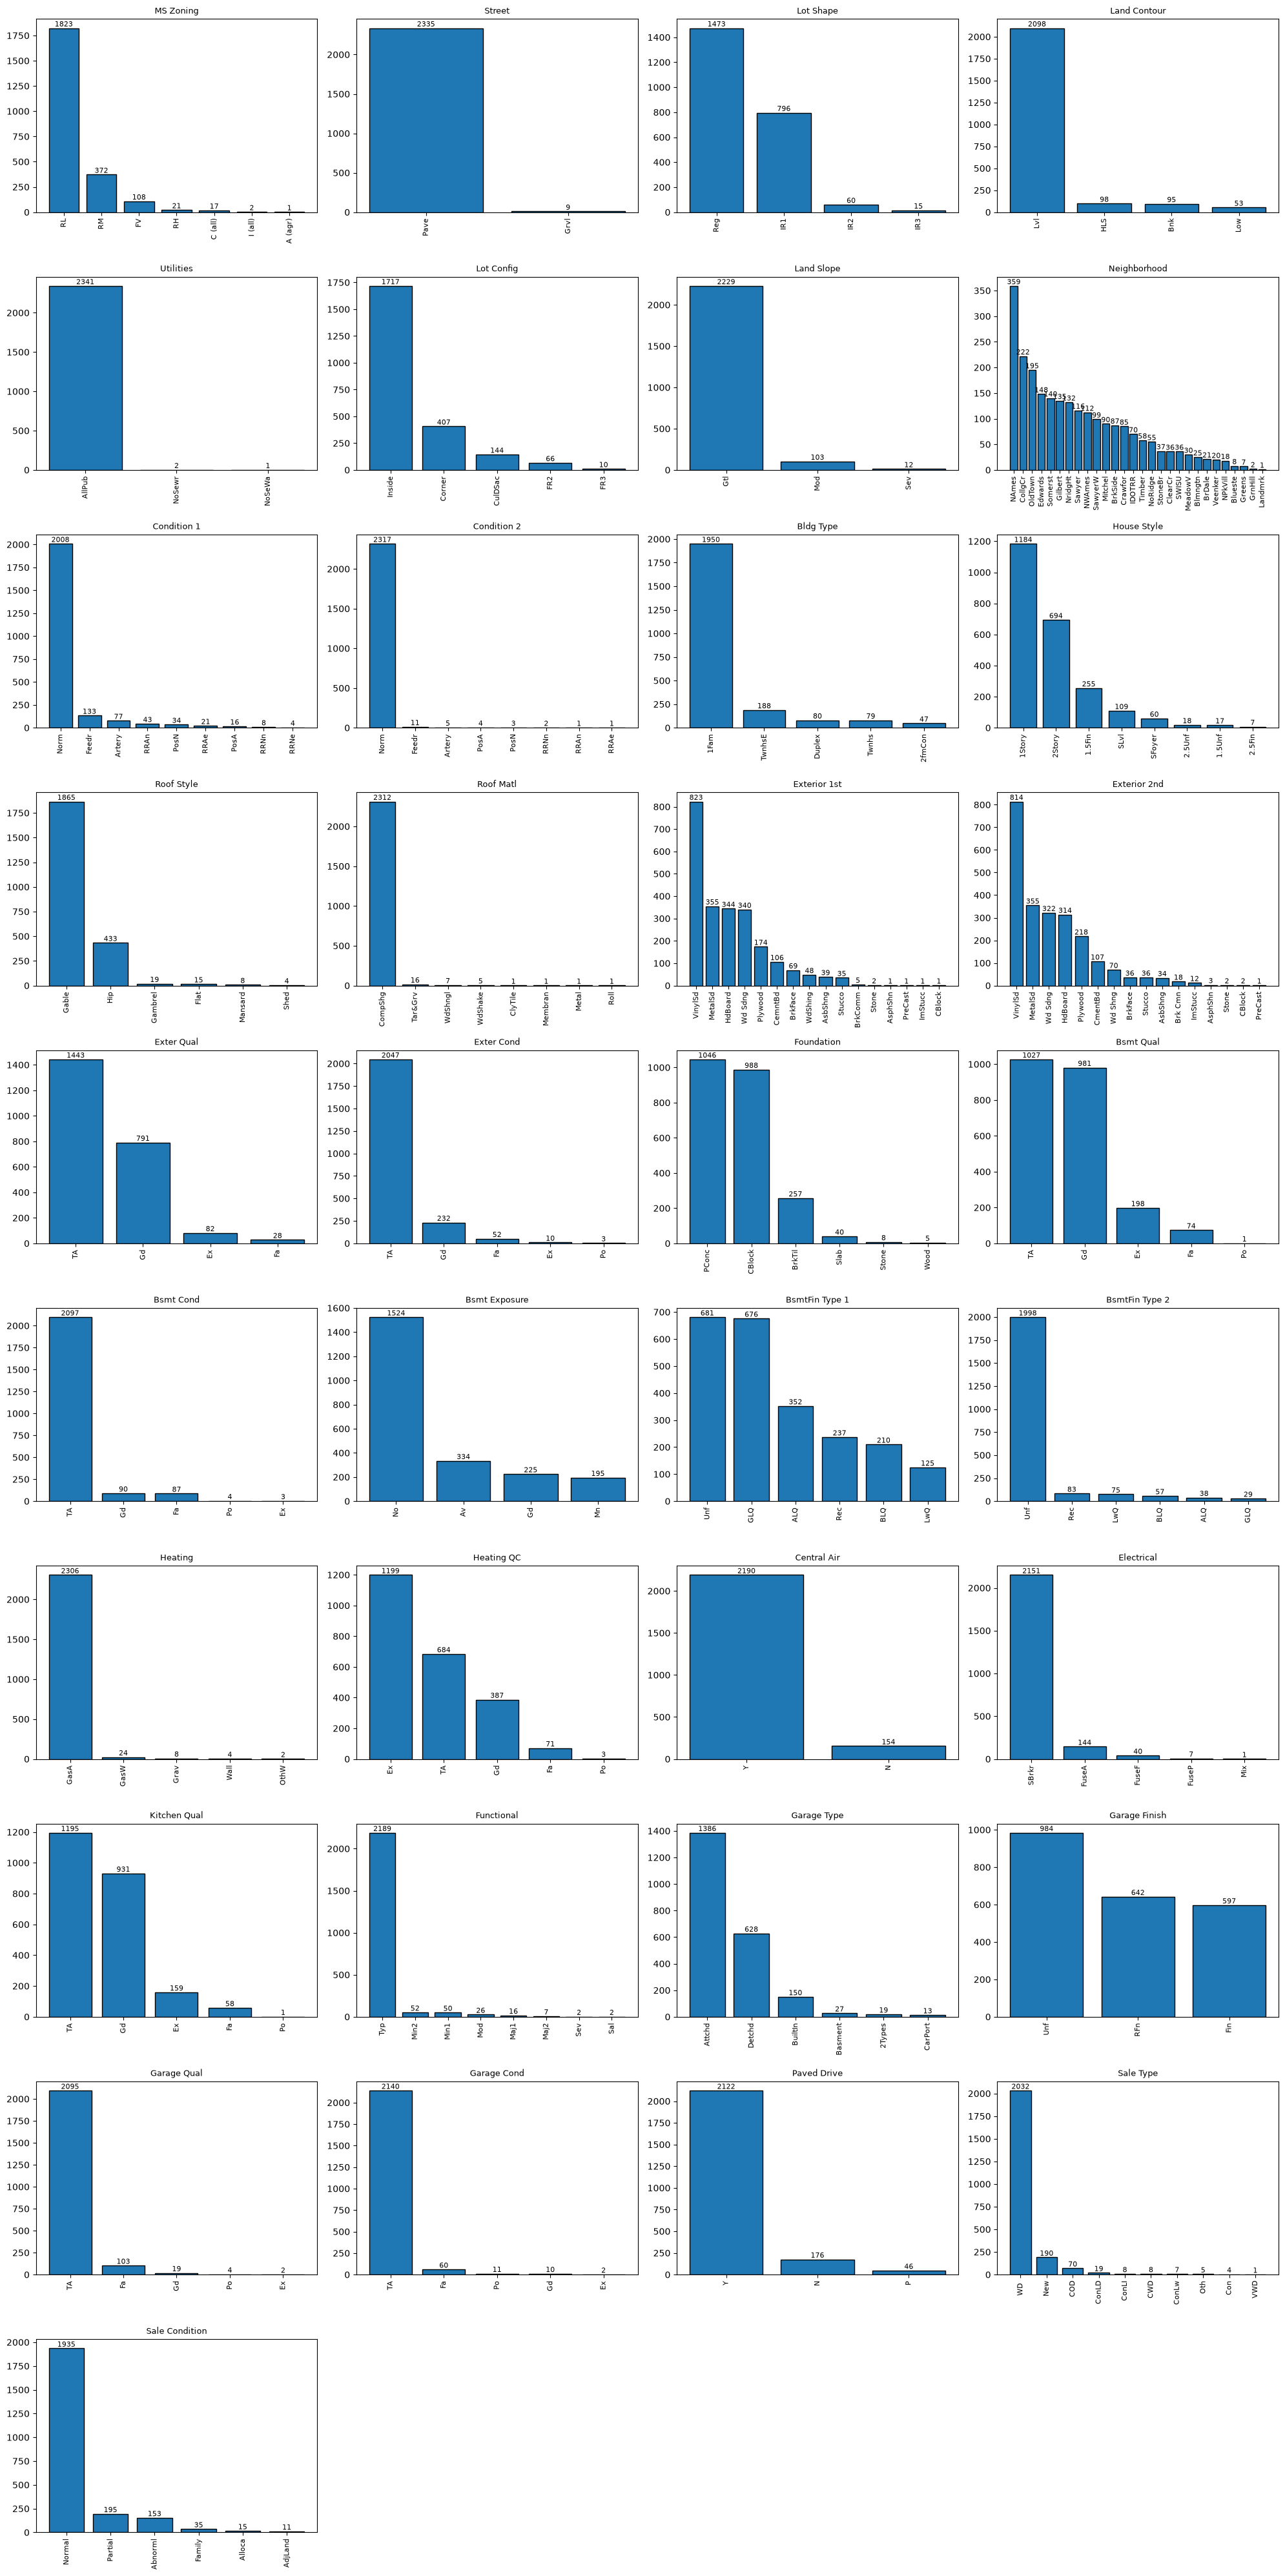

In [92]:
n_cols = 4
n_rows = -(-len(cat_cols_filtered) // n_cols)  # round up

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_filtered):
    counts = train_df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, edgecolor="black")

    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', rotation=90, labelsize=8)

    for bar, value in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                      str(value), ha='center', va='bottom', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

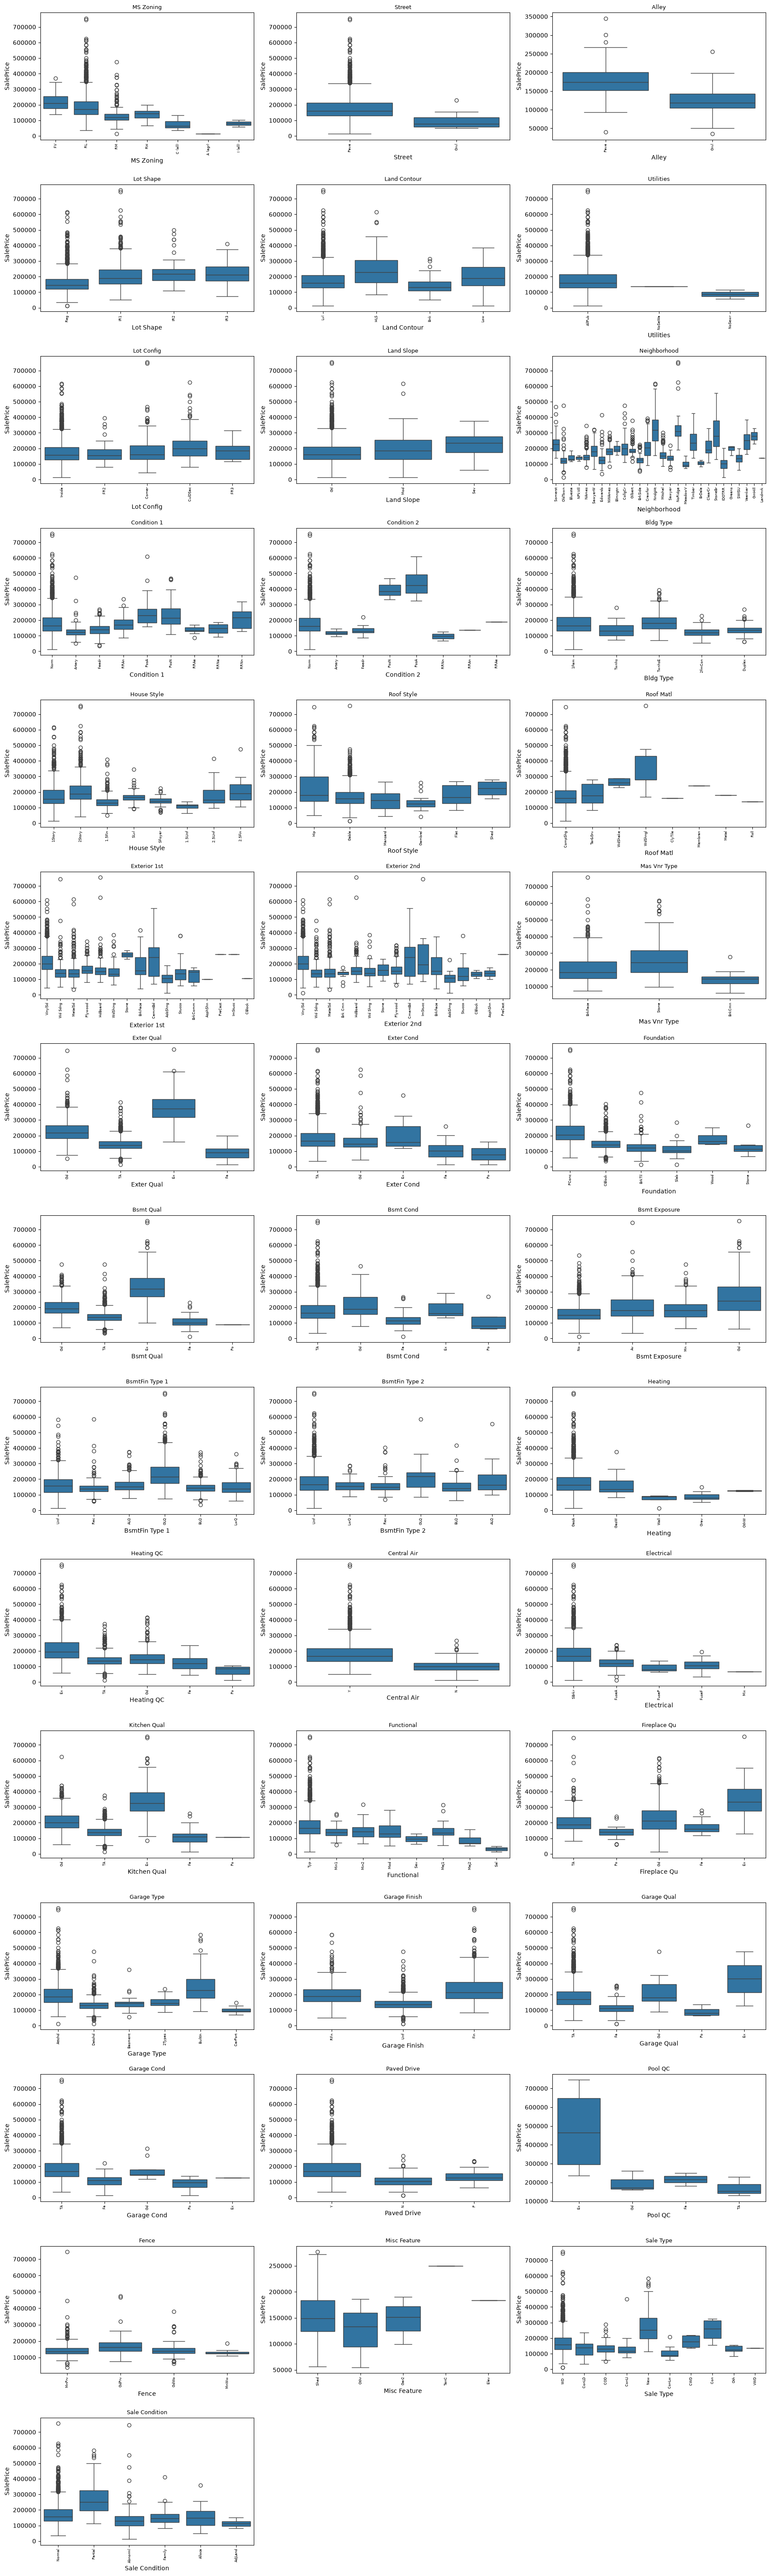

In [77]:
n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)  # round up

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=train_df, x=col, y="SalePrice", ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', rotation=90, labelsize=6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [99]:
# ranking categorical columns by how much their group median spreads out. Used as a rough proxy for "does this matter for price"
cat_cols_filtered = [col for col in cat_cols if col not in cols_to_drop]

spread = {}
for col in cat_cols_filtered:
    medians = train_df.groupby(col)["SalePrice"].median()
    spread[col] = medians.max() - medians.min()

spread_ranked = pd.Series(spread).sort_values(ascending=False)
spread_ranked.head(39)

Condition 2      3.27e+05
Exter Qual       2.80e+05
Bsmt Qual        2.29e+05
Neighborhood     2.27e+05
Garage Qual      2.20e+05
Kitchen Qual     2.18e+05
MS Zoning        1.97e+05
Sale Type        1.72e+05
Exterior 1st     1.62e+05
Exterior 2nd     1.52e+05
Roof Matl        1.43e+05
Sale Condition   1.37e+05
Functional       1.32e+05
Garage Type      1.32e+05
Bsmt Cond        1.09e+05
Heating QC       1.08e+05
Condition 1      1.07e+05
Foundation       1.02e+05
Electrical       1.00e+05
Roof Style       1.00e+05
Land Contour     9.57e+04
Bsmt Exposure    9.21e+04
Exter Cond       8.85e+04
Street           8.22e+04
Heating          8.18e+04
Garage Finish    7.85e+04
House Style      7.80e+04
BsmtFin Type 1   7.80e+04
BsmtFin Type 2   7.75e+04
Land Slope       7.53e+04
Utilities        7.37e+04
Lot Shape        7.22e+04
Garage Cond      7.15e+04
Central Air      6.60e+04
Paved Drive      6.33e+04
Bldg Type        6.01e+04
Lot Config       4.45e+04
dtype: float64

In [103]:
remaining_top = [col for col in spread_ranked.head(15).index if col not in cols_to_drop]

for col in remaining_top:
    counts = train_df[col].value_counts()
    print(f"{col}: spread={spread_ranked[col]:,.0f}, smallest category n={counts.min()}, categories={len(counts)}")

Condition 2: spread=326,750, smallest category n=1, categories=8
Exter Qual: spread=280,189, smallest category n=28, categories=4
Bsmt Qual: spread=229,030, smallest category n=1, categories=5
Neighborhood: spread=227,000, smallest category n=1, categories=28
Garage Qual: spread=219,500, smallest category n=2, categories=5
Kitchen Qual: spread=217,500, smallest category n=1, categories=5
MS Zoning: spread=197,100, smallest category n=1, categories=7
Sale Type: spread=171,615, smallest category n=1, categories=10
Exterior 1st: spread=162,000, smallest category n=1, categories=16
Exterior 2nd: spread=152,000, smallest category n=1, categories=16
Roof Matl: spread=143,000, smallest category n=1, categories=8
Sale Condition: spread=137,000, smallest category n=11, categories=6
Functional: spread=132,450, smallest category n=2, categories=8
Garage Type: spread=131,959, smallest category n=13, categories=6
Bsmt Cond: spread=108,725, smallest category n=3, categories=5
